In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_dataset

In [3]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 0. Setup

In [4]:
import torch
print("CUDA available:", torch.cuda.is_available())


CUDA available: True


In [5]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Jul 24 04:46:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   56C    P8             17W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# # Might need to sip Install PyTorch (official + CUDA 11.8  need cuda 117 compatible version for Colab)
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [6]:
# Test tensor operation on GPU
x = torch.tensor([1.0, 2.0]).to("cuda" if torch.cuda.is_available() else "cpu")
print("Tensor on device:", x.device)

Tensor on device: cuda:0


In [11]:
# # This need to be reinstalled
# # Install torch-scatter, torch-sparse, torch-cluster, torch-spline-conv (for PyG)
# !pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
# !pip install -q torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
# !pip install -q torch-cluster -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
# !pip install -q torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

In [7]:
# Downgrade PyTorch to a compatible version (2.0.0+cu117)
!pip install torch==2.0.0+cu117 torchvision==0.15.1+cu117 torchaudio==2.0.1 --index-url https://download.pytorch.org/whl/cu117

# Install correct GNN dependencies
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install torch-geometric -U


Looking in indexes: https://download.pytorch.org/whl/cu117
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu117.html
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu117.html


In [8]:
import pyg_lib
print("pyg-lib is loaded successfully")


pyg-lib is loaded successfully


In [9]:
import torch
print(torch.__version__)  # Should be 2.0.0 if using cu117 links

2.0.0+cu117


In [10]:
# Install PyTorch + CUDA 11.7 compatible packages from PyG wheels
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install -q torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.0+cu117.html
!pip install -q torch-geometric


In [11]:
# tqdm and numpy for data loading and preprocessing
!pip install -q tqdm

In [12]:
!pip install numpy==1.26.4

In [13]:
# test package installation
import torch_geometric
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
print("PyG version:", torch_geometric.__version__)

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.0+cu117


PyG version: 2.6.1


In [14]:
!pip install scikit-learn==1.3.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 125.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
cuml-cu12 25.6.0 requires scikit-learn>=1.5, but you have scikit-learn 1.3.2 which is incompatible.


# 1 Loading data

In [15]:
data_path = '/content/drive/MyDrive/CS7643-GroupProject/Data/items_cleaned.csv'
items_df = pd.read_csv(data_path)
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402691 entries, 0 to 402690
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   item_Id                 402691 non-null  int64  
 1   ASIN                    402691 non-null  object 
 2   title                   402691 non-null  object 
 3   group                   402691 non-null  object 
 4   similar                 306655 non-null  object 
 5   category_count          402691 non-null  int64  
 6   salesrank_log           402691 non-null  float64
 7   reviews_total_log       402691 non-null  float64
 8   reviews_downloaded_log  402691 non-null  float64
 9   category_path_1         402691 non-null  object 
 10  category_path_2         402691 non-null  object 
 11  category_path_3         402691 non-null  object 
 12  category_path_4         402691 non-null  object 
 13  reviews_avg_ratings     402691 non-null  float64
 14  reviews_avg_votes   

In [16]:
print(items_df['similar'].describe())
print(items_df['similar'].dtype)
print(items_df['similar'].unique())

count         306655
unique        258147
top       B00008LDNZ
freq             215
Name: similar, dtype: object
object
['0804215715,156101074X,0687023955,0687074231,082721619X'
 '0738700827,1567184960,1567182836,0738700525,0738700940' nan ...
 '630366704X' '1580510469,0896229939' 'B00005O6KL,B0000634HG']


In [17]:
print(items_df['similar'][:10])

0    0804215715,156101074X,0687023955,0687074231,08...
1    0738700827,1567184960,1567182836,0738700525,07...
2                                                  NaN
3                                           0842328610
4          0486401960,0452283612,0486229076,0714840343
5                     B0000261KX,B00006AM8D,B000059OB9
6          B000067D0Y,0375727191,1560232579,0300089023
7    039474067X,0679730672,0679750541,1400030668,08...
8          0060984341,0553577514,1571742972,0962741817
9                                           0871319640
Name: similar, dtype: object


In [ ]:
# GraphSage with embedded feature (2)

In [18]:
!ls "/content/drive/MyDrive/CS7643-GroupProject/Data/feature_embedding"


category_feature_option2.npy   features_matrix_title_pca_nocat.npy
feature_matrix_no_cat.npy      features_matrix_title_pca_nocat.npy.npz
feature_matrix_no_cat.npy.npz  item_id.npy


In [19]:

# load category embedded feature with option 2 embedding method. Label Encoding + Embedding
data_path = '/content/drive/MyDrive/CS7643-GroupProject/Data/feature_embedding/category_feature_option2.npy'
category_np = np.load(data_path, allow_pickle=True)
print(category_np[:1])
# embedded_dim 64 + item_id_1
print(category_np.shape)
print(type(category_np))

[[-1.02297199e+00  1.22090980e-01  9.10708964e-01 -1.15172279e+00
  -4.28893119e-02 -6.55704498e-01  1.36708349e-01 -4.49422002e-01
   3.42966259e-01  4.08214718e-01 -2.33698204e-01  6.40505433e-01
   5.49989641e-01 -2.95777798e-01 -3.76500189e-01 -9.98360738e-02
  -1.59998834e-01  4.53040719e-01  2.81183958e-01 -7.58829266e-02
  -1.13502526e+00  4.83586863e-02  2.91827619e-01  3.99585038e-01
  -7.33323216e-01 -3.36673886e-01  5.25386453e-01 -7.65288621e-02
  -5.02048135e-01  6.65346503e-01  4.82856125e-01 -2.73816288e-01
   8.70063901e-04 -2.51180440e-01 -1.70295879e-01 -1.05823368e-01
   3.84430766e-01  1.66155100e-01  5.04284725e-02 -4.81092751e-01
   1.00041300e-01  9.53967869e-01  4.03433591e-01 -8.05271029e-01
   7.53990650e-01 -2.37683475e-01 -7.24423766e-01 -4.21068221e-01
  -1.83440000e-02  5.26307881e-01  3.86980653e-01 -6.88544393e-01
  -4.45904553e-01 -5.95013857e-01  1.05948520e+00  1.37100786e-01
   9.59451258e-01 -9.86866653e-03 -2.47477889e-02 -2.12853119e-01
  -4.50222

In [20]:
# remove the last item ID column
category_np = category_np[:, :-1]
print(category_np.shape)

(402691, 64)


In [21]:
# load embedded feature which has everything except category.
data_path = '/content/drive/MyDrive/CS7643-GroupProject/Data/feature_embedding/feature_matrix_no_cat.npy'
feature_nocat_np = np.load(data_path, allow_pickle=True)
# print(feature_nocat_np[:1])
# title_embedding 384, group 10, numeric 7
print(feature_nocat_np.shape)

(402691, 401)


In [22]:
# load item_id
data_path = '/content/drive/MyDrive/CS7643-GroupProject/Data/feature_embedding/item_id.npy'
item_id_np = np.load(data_path, allow_pickle=True)
print(item_id_np.shape)

(402691,)


#2. Model implementation


required input:


1.   Node features X as a NumPy array, convert to torch.sensor
2.   Positive and Negative edges (edge_label_index)
3.   Labels (edge_labels), 1, and 0.


| Input              | Shape                       | Required?  | Description               |
| ------------------ | --------------------------- | ---------- | ------------------------- |
| `x`                | `[num_nodes, num_features]` | ✅          | Node features             |
| `edge_index`       | `[2, num_edges]`            | ✅          | Observed positive edges, Graph Structure   |
| `edge_label_index` | `[2, num_pos + num_neg]`    | ✅ | Edges to predict, supervised edge pair          |
| `edge_label`       | `[num_pos + num_neg]`       | ✅  | Ground truth labels (0/1) |


###2.1 X = [num_nodes, num_features]

In [23]:
embedded_features = np.concatenate((feature_nocat_np,category_np), axis=1)
x = torch.tensor(embedded_features, dtype=torch.float)
print(x.shape)

torch.Size([402691, 465])


###2.2 Edge preparation

In [24]:
# Build positive edge list (why use ASIN?)
# Node indices from 0 to N-1, contiguous and dense, for edge_index, X, etc.
# build asin number to dense node index mapping
df = items_df.copy()
df['node_idx'] = df.index
asin_idx = dict(zip(df['ASIN'], df['node_idx']))
idx_asin = dict(zip(df['node_idx'], df['ASIN']))

positive_edges = set()
for _, row in df.iterrows():
    source = row['node_idx']
    # filter out missings in similar column
    if not isinstance(row['similar'], str):
        continue
    similar_asin = row['similar'].split(',')
    for asin in similar_asin:
      asin = asin.strip()
      target = asin_idx.get(asin)
      if target is not None:
        # create undirected edge
        edge = tuple(sorted((source, target)))
        positive_edges.add(edge)

positive_edges = list(positive_edges)

In [25]:
len(positive_edges)

808185

In [26]:
# step2: collect all nodes from cleaned dataset
all_nodes = set(df['node_idx'].unique())

In [27]:
# step3: negative sampling with ratio n
import random
def generate_negative_edges(positive_edges, all_nodes, neg_ratio = 1):
    negative_edges = set()
    positive_edges = set(positive_edges)
    all_nodes = list(all_nodes)
    num_samples = len(positive_edges) * neg_ratio
    while len(negative_edges) < num_samples:
      source = random.choice(all_nodes)
      target = random.choice(all_nodes)
      if source != target:
        edge = tuple(sorted((source, target)))
        if edge not in positive_edges and edge not in negative_edges:
          negative_edges.add(edge)
    return list(negative_edges)

In [28]:
# step4: create training labels
negative_edges = generate_negative_edges(positive_edges, all_nodes, neg_ratio = 1)
positive_df = pd.DataFrame(positive_edges, columns=['source', 'target'])
positive_df['label'] = 1
negative_df = pd.DataFrame(negative_edges, columns=['source', 'target'])
negative_df['label'] = 0
edge_df = pd.concat([positive_df, negative_df], ignore_index=True)
edge_df = edge_df.sample(frac=1).reset_index(drop=True)

In [29]:
print(edge_df.head())
print(edge_df.shape)

   source  target  label
0  137030  140690      0
1   20700   84492      0
2  117301  370104      0
3   41358  388627      1
4  121111  369415      0
(1616370, 3)


In [30]:
from google.colab import files
edge_df.to_csv("/content/drive/MyDrive/CS7643-GroupProject/Data/edge", index=False)

In [31]:
# Convert edge_df to edge_label_index and edge_label for PyG
edge_label_index = edge_df[['source', 'target']].to_numpy().T # shape [2, num_edges]
edge_labels = edge_df['label'].values # shape [num_edges]

# convert to torch tensors
edge_label_index = torch.tensor(edge_label_index, dtype=torch.long)
edge_labels = torch.tensor(edge_labels, dtype=torch.float)

In [32]:
# Convert positive edges into edge_index
edge_indexes_np = np.array(positive_edges).T
edge_index = torch.tensor(edge_indexes_np, dtype=torch.long)

In [33]:
print(edge_label_index.shape) # [2, num_edges]
print(edge_labels.shape) # shape [num_edges]
print(edge_index.shape) # [2, num_pos_edges]

torch.Size([2, 1616370])
torch.Size([1616370])
torch.Size([2, 808185])


## 2.3 Train GraphSAGE

GraphSAGE Architecture Model ref https://deepgnn.readthedocs.io/en/latest/torch/link_pred.html#

It’s a custom decoder for link prediction, where:

It Take two node embeddings: x_i, x_j

Combine them (using element-wise product: x_i * x_j)

Feed that into an MLP (multi-layer perceptron) with dropout

Output a probability via torch.sigmoid(x)

### Model implementation

In [34]:
# Build the GraphSAGE Model
# Step1 Define GraphSAGE Encoder
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

# Step2 : Define LinkPrediction/ Decoder (code from references)

class LinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout):
        super().__init__()
        self.lins = torch.nn.ModuleList()
        self.lins.append(torch.nn.Linear(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.lins.append(torch.nn.Linear(hidden_channels, hidden_channels))
        self.lins.append(torch.nn.Linear(hidden_channels, out_channels))
        self.dropout = dropout

    def reset_parameters(self):
        for lin in self.lins:
            lin.reset_parameters()

    def forward(self, x_i, x_j):
        x = x_i * x_j
        for lin in self.lins[:-1]:   # MLP, Real-world recommendations of GNN.
            x = F.relu(lin(x))
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lins[-1](x)
        return torch.sigmoid(x)  # probability of the link



In [35]:
def build_model(config):
    encoder = GraphSAGE(
        in_channels=config['in_channels'],
        hidden_channels=config['hidden_channels'],
        out_channels=config['hidden_channels']  # latent embedding size
    )
    predictor = LinkPredictor(
        in_channels=config['hidden_channels'],
        hidden_channels=config['hidden_channels'],
        out_channels=config['out_channels'],
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )
    return encoder, predictor



###Train/Test split

In [36]:
# Inductive split by node to avoid simple training
import numpy as np

# Step 1: Collect all unique nodes
all_nodes = list(set(edge_df['source']) | set(edge_df['target']))
np.random.seed(42)
np.random.shuffle(all_nodes)

# Step 2: Split nodes into train/test sets
num_nodes = len(all_nodes)
train_nodes = set(all_nodes[:int(0.8 * num_nodes)])
test_nodes  = set(all_nodes[int(0.8 * num_nodes):])

# Step 3: Keep only edges where both endpoints are in the same node split
train_df = edge_df[edge_df['source'].isin(train_nodes) & edge_df['target'].isin(train_nodes)]
test_df  = edge_df[edge_df['source'].isin(test_nodes)  & edge_df['target'].isin(test_nodes)]

# shuffle again
train_df = train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(frac=1.0, random_state=42).reset_index(drop=True)


In [37]:
# create train/test_edge_index , train/test_edge_label

def df_to_edge_tensor(df):
    edge_index = torch.tensor(df[['source', 'target']].to_numpy().T, dtype=torch.long)
    edge_label = torch.tensor(df['label'].to_numpy(), dtype=torch.float)
    return edge_index, edge_label

train_edge_index, train_edge_label = df_to_edge_tensor(train_df)
test_edge_index, test_edge_label = df_to_edge_tensor(test_df)


In [38]:
# inductive link prediction>>>>>> edges are splited, but nodes are shared??
# confirm there is no transductive split.
# 1. Get all nodes from train and test sets
train_nodes = set(train_df['source']) | set(train_df['target'])
test_nodes  = set(test_df['source']) | set(test_df['target'])

# 2. Find overlapping nodes
shared_nodes = train_nodes & test_nodes

# 3. Print result
print(f"Number of shared nodes: {len(shared_nodes)}")
print(f"Shared nodes example: {list(shared_nodes)[:10]}")

Number of shared nodes: 0
Shared nodes example: []


##### Mini-batch link prediction with Neighborloader.

NeighborLoader is a utility in PyTorch Geometric (PyG) that enables mini-batch training on large graphs by:

Sampling subgraphs (a few nodes + their neighbors)

Loading only the part of the graph needed for each mini-batch

Making GraphSAGE (and other GNNs) scalable to large datasets like Amazon

It's basically a graph-aware data loader, like a DataLoader, but specialized for neighborhood sampling in graphs.

In [39]:
# Construct PyG object after train/test split
from torch_geometric.data import Data

data = Data(
    x=x,
    edge_index=edge_index,                     # full graph structure
    edge_label_index=train_edge_index,         # edges to supervise
    edge_label=train_edge_label                # binary labels
)

# debug. change tensor to
data.x = data.x.contiguous()
data.edge_index = data.edge_index.contiguous()
data.edge_label_index = data.edge_label_index.contiguous()
data.edge_label = data.edge_label.contiguous()


In [40]:
# Create the Training LinkNeighborLoader
# Batchsize: can be adjusted based on GPU type. A100 can handle larger one. if use T4, then decrease batch size

from torch_geometric.loader import LinkNeighborLoader
train_loader = LinkNeighborLoader(
    data,
    edge_label_index=data.edge_label_index,
    edge_label=data.edge_label,
    num_neighbors = [10,10],   # sample 10 neighbors at 1-hop and 2-hop layer.
    batch_size = 1024, # number of edges (not nodes) per mini-batch
    shuffle = True  # shuffle edge order
)

In [41]:
# create the Test(Val) LinkNeighborloader
data.edge_label_index = test_edge_index  # test = val in your case
data.edge_label = test_edge_label
val_loader = LinkNeighborLoader(
    data,
    edge_label_index=test_edge_index,
    edge_label=test_edge_label,
    num_neighbors=[10, 10],
    batch_size=1024,
    shuffle=False
)

In [42]:
def check_tensor_devices():
    print("data.x:", data.x.device)
    print("data.edge_index:", data.edge_index.device)
    print("train_edge_index:", data.edge_index.device)
    print("train_edge_label:", data.edge_label.device)
    print("encoder:", next(encoder.parameters()).device)
    print("predictor:", next(predictor.parameters()).device)



In [43]:
# Model Initialization
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = {
    'in_channels': data.x.size(1),
    'hidden_channels': 64,
    'out_channels': 1,
    'num_layers': 3,
    'dropout': 0.5,
    'lr': 0.01
}


In [44]:
 # Training setup
encoder, predictor = build_model(config)
encoder = encoder.to(device)
predictor = predictor.to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=config['lr']
)



In [45]:
# Define loss function for imbalanced dataset
from torch.nn import BCEWithLogitsLoss

# Compute pos_weight = N_negative / N_positive
num_pos = train_df['label'].sum()
num_neg = len(train_df) - num_pos
pos_weight = torch.tensor([num_neg / num_pos]).to(device)

loss_fn = BCEWithLogitsLoss(pos_weight=pos_weight)


In [46]:
import numpy as np
print(np.__version__)


1.26.4


In [ ]:
# Implement early stopping based on validation AUC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time
import copy
import numpy as np

total_time = 0.0
metrics = []

best_val_auc = 0
best_epoch = 0
best_model_state = None
patience = 20
patience_counter = 0

for epoch in range(1, 101):
    epoch_start = time.time()

    encoder.train()
    predictor.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for batch in train_loader:
        batch = batch.to(device)

        z = encoder(batch.x, batch.edge_index)
        src, dst = batch.edge_label_index
        pred = predictor(z[src], z[dst]).squeeze()
        label = batch.edge_label

        loss = loss_fn(pred, label)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()
        train_preds.append(pred.detach().cpu())
        train_labels.append(label.cpu())

    y_prob_train = torch.cat(train_preds).sigmoid()
    y_pred_train = y_prob_train > 0.5
    y_true_train = torch.cat(train_labels)

    train_acc = accuracy_score(y_true_train, y_pred_train)
    train_prec = precision_score(y_true_train, y_pred_train, zero_division=0)
    train_rec = recall_score(y_true_train, y_pred_train, zero_division=0)
    train_f1 = f1_score(y_true_train, y_pred_train, zero_division=0)
    train_auc = roc_auc_score(y_true_train, y_prob_train)
    train_loss /= len(train_loader)

    # Validation
    encoder.eval()
    predictor.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            z = encoder(batch.x, batch.edge_index)
            src, dst = batch.edge_label_index
            pred = predictor(z[src], z[dst]).squeeze()
            label = batch.edge_label

            loss = loss_fn(pred, label)
            val_loss += loss.item()
            val_preds.append(pred.cpu())
            val_labels.append(label.cpu())

    y_prob_val = torch.cat(val_preds).sigmoid()
    y_pred_val = y_prob_val > 0.5
    y_true_val = torch.cat(val_labels)

    val_acc = accuracy_score(y_true_val, y_pred_val)
    val_prec = precision_score(y_true_val, y_pred_val, zero_division=0)
    val_rec = recall_score(y_true_val, y_pred_val, zero_division=0)
    val_f1 = f1_score(y_true_val, y_pred_val, zero_division=0)
    val_auc = roc_auc_score(y_true_val, y_prob_val)
    val_loss /= len(val_loader)

    epoch_time = time.time() - epoch_start
    total_time += epoch_time

    print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | F1: {train_f1:.4f} | AUC: {train_auc:.4f} || "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f} | "
          f"Time: {epoch_time:.2f}s")

    metrics.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'train_prec': train_prec,
        'train_rec': train_rec,
        'train_f1': train_f1,
        'train_auc': train_auc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_prec': val_prec,
        'val_rec': val_rec,
        'val_f1': val_f1,
        'val_auc': val_auc,
        'epoch_time': epoch_time
    })

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        best_model_state = {
            'encoder': copy.deepcopy(encoder.state_dict()),
            'predictor': copy.deepcopy(predictor.state_dict())
        }
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

print(f"\n Total training time: {total_time:.2f} seconds")
print(f"Best epoch: {best_epoch} | Best Val AUC: {best_val_auc:.4f}")


In [ ]:
from google.colab import files
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("metrics.csv", index=False)
metrics_df.to_csv("/content/drive/MyDrive/CS7643-GroupProject/Data/GraphSAGE_metrics/metrics.csv", index=False)



In [ ]:
# # Full batch mode with A100 ONLY!
# from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, average_precision_score
# import time

# # with train time

# total_time = 0.0
# metrics = []
# for epoch in range(1, 101):
#     start_time = time.time()

#     encoder.train()
#     predictor.train()
#     optimizer.zero_grad()

#     z = encoder(data.x, data.edge_index)
#     src, dst = train_edge_index
#     train_logits = predictor(z[src], z[dst]).squeeze()  # no sigmoid!
#     train_loss = loss_fn(train_logits, train_edge_label)

#     train_loss.backward()
#     optimizer.step()

#     # Evaluation
#     encoder.eval()
#     predictor.eval()
#     with torch.no_grad():
#         z = encoder(data.x, data.edge_index)

#         test_src, test_dst = test_edge_index
#         test_logits = predictor(z[test_src], z[test_dst]).squeeze()  # raw logits
#         test_probs = torch.sigmoid(test_logits)  # only apply sigmoid here
#         test_preds = (test_probs > 0.5).int()

#         test_loss = loss_fn(test_logits, test_edge_label).item()
#         test_auc = roc_auc_score(test_edge_label.cpu(), test_probs.cpu())
#         test_ap  = average_precision_score(test_edge_label.cpu(), test_probs.cpu())
#         test_acc = accuracy_score(test_edge_label.cpu(), test_preds.cpu())
#         test_prec = precision_score(test_edge_label.cpu(), test_preds.cpu())
#         test_recall = recall_score(test_edge_label.cpu(), test_preds.cpu())
#         test_f1 = f1_score(test_edge_label.cpu(), test_preds.cpu())

#         # Also compute train AUC for monitoring
#         train_probs = torch.sigmoid(train_logits)
#         train_auc = roc_auc_score(train_edge_label.cpu(), train_probs.cpu())
#         train_acc = accuracy_score(train_edge_label.cpu(), (train_probs > 0.5).int().cpu())



#     epoch_time = time.time() - start_time
#     total_time += epoch_time

#     print(f"Epoch {epoch:03d} | Train Loss: {train_loss.item():.4f} |Train Acc: {train_acc:.4f}| "
#           f"Test Loss: {test_loss:.4f} |Test Acc: {test_acc:.4f} "
#           f"Time: {epoch_time:.2f}s")

#     metrics.append({
#         'epoch': epoch,
#         'train_loss': train_loss.item(),
#         'train_auc': train_auc,
#         'train_acc': train_acc,
#         'test_loss': test_loss,
#         'test_auc': test_auc,
#         'test_acc': test_acc,
#         'precision': test_prec,
#         'recall': test_recall,
#         'f1': test_f1,
#         'pr_auc': test_ap,
#         'epoch_time': epoch_time
#     })

# print(f"\nTotal training time: {total_time:.2f} seconds")
# metrics_df = pd.DataFrame(metrics)



#Hyperparameter tuning

In [ ]:
import random
def random_config():
    return {
        'hidden_channels': random.choice([32, 64, 128]),
        'num_layers': random.choice([2, 3]),
        'dropout': random.choice([0.3, 0.5]),
        'lr': random.choice([1e-2, 5e-3, 1e-3]),
        'batch_size': random.choice([512, 1024]),
        'num_neighbors': random.choice([[5, 5], [10, 10], [15, 10]]),
    }


In [ ]:
# convert the model trianing in to a helper function
def train_model(
    encoder, predictor,
    train_loader, val_loader,
    loss_fn, optimizer,
    device,
    max_epochs=100,
    patience=10
):
    total_time = 0.0
    metrics = []

    best_val_auc = 0
    best_epoch = 0
    best_model_state = None
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()

        encoder.train()
        predictor.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in train_loader:
            batch = batch.to(device)

            z = encoder(batch.x, batch.edge_index)
            src, dst = batch.edge_label_index
            pred = predictor(z[src], z[dst]).squeeze()
            label = batch.edge_label

            loss = loss_fn(pred, label)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()
            train_preds.append(pred.detach().cpu())
            train_labels.append(label.cpu())

        y_prob_train = torch.cat(train_preds).sigmoid()
        y_pred_train = y_prob_train > 0.5
        y_true_train = torch.cat(train_labels)

        train_acc = accuracy_score(y_true_train, y_pred_train)
        train_prec = precision_score(y_true_train, y_pred_train, zero_division=0)
        train_rec = recall_score(y_true_train, y_pred_train, zero_division=0)
        train_f1 = f1_score(y_true_train, y_pred_train, zero_division=0)
        train_auc = roc_auc_score(y_true_train, y_prob_train)
        train_loss /= len(train_loader)

        # Validation
        encoder.eval()
        predictor.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                z = encoder(batch.x, batch.edge_index)
                src, dst = batch.edge_label_index
                pred = predictor(z[src], z[dst]).squeeze()
                label = batch.edge_label

                loss = loss_fn(pred, label)
                val_loss += loss.item()
                val_preds.append(pred.cpu())
                val_labels.append(label.cpu())

        y_prob_val = torch.cat(val_preds).sigmoid()
        y_pred_val = y_prob_val > 0.5
        y_true_val = torch.cat(val_labels)

        val_acc = accuracy_score(y_true_val, y_pred_val)
        val_prec = precision_score(y_true_val, y_pred_val, zero_division=0)
        val_rec = recall_score(y_true_val, y_pred_val, zero_division=0)
        val_f1 = f1_score(y_true_val, y_pred_val, zero_division=0)
        val_auc = roc_auc_score(y_true_val, y_prob_val)
        val_loss /= len(val_loader)

        epoch_time = time.time() - epoch_start
        total_time += epoch_time

        print(f"Epoch {epoch:03d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | F1: {train_f1:.4f} | AUC: {train_auc:.4f} || "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f} | "
              f"Time: {epoch_time:.2f}s")

        metrics.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'train_prec': train_prec,
            'train_rec': train_rec,
            'train_f1': train_f1,
            'train_auc': train_auc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_prec': val_prec,
            'val_rec': val_rec,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'epoch_time': epoch_time
        })

        # Early stopping use AUC as signal
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch
            best_model_state = {
                'encoder': copy.deepcopy(encoder.state_dict()),
                'predictor': copy.deepcopy(predictor.state_dict())
            }
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    print(f"\nTotal training time: {total_time:.2f} seconds")
    print(f"Best epoch: {best_epoch} | Best Val AUC: {best_val_auc:.4f}")

    return best_val_auc, best_epoch, best_model_state, metrics


In [ ]:
import os
import json
import pandas as pd
from datetime import datetime
import copy
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define data path
data_path = '/content/drive/MyDrive/CS7643-GroupProject/Data/'

# Set number of trials
NUM_TRIALS = 30

# Base output folder
base_dir = os.path.join(data_path, "tuning_results_round3")
os.makedirs(base_dir, exist_ok=True)

for trial in range(1, NUM_TRIALS + 1):
    config = random_config()
    print(f"\Trial {trial}/{NUM_TRIALS} - Config: {config}")

    # 1. Rebuild model
    config['in_channels'] = data.x.size(1)
    config['out_channels'] = 1
    encoder, predictor = build_model(config)
    encoder = encoder.to(device)
    predictor = predictor.to(device)

    #  2. Optimizer & Loss
    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(predictor.parameters()),
        lr=config['lr']
    )

    num_pos = train_df['label'].sum()
    num_neg = len(train_df) - num_pos
    pos_weight = torch.tensor([num_neg / num_pos]).to(device)
    loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # 3. NeighborLoader
    train_loader = LinkNeighborLoader(
        data,
        edge_label_index=train_edge_index,
        edge_label=train_edge_label,
        num_neighbors=config['num_neighbors'],
        batch_size=config['batch_size'],
        shuffle=True
    )
    val_loader = LinkNeighborLoader(
        data,
        edge_label_index=test_edge_index,
        edge_label=test_edge_label,
        num_neighbors=config['num_neighbors'],
        batch_size=config['batch_size'],
        shuffle=False
    )

    # Train model
    best_auc, best_epoch, best_state, metrics = train_model(
        encoder, predictor,
        train_loader, val_loader,
        loss_fn, optimizer,
        device=device,
        max_epochs=100,
        patience=10
    )

    # Save results
    run_id = f"trial_{trial:02d}_auc_{best_auc:.4f}"
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = os.path.join(base_dir, f"{run_id}_{timestamp}")
    os.makedirs(save_dir, exist_ok=True)

    # Save config
    with open(os.path.join(save_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    # Save metrics
    pd.DataFrame(metrics).to_csv(os.path.join(save_dir, "metrics.csv"), index=False)

    # Save model
    torch.save(best_state['encoder'], os.path.join(save_dir, "best_encoder.pt"))
    torch.save(best_state['predictor'], os.path.join(save_dir, "best_predictor.pt"))

    print(f" Saved run to {save_dir}")


# Optimal Results

In [49]:
# Select the optimal parameter to finish the whole epoch:
# Config: {'hidden_channels': 32, 'num_layers': 2, 'dropout': 0.3,
# 'lr': 0.001, 'batch_size': 1024, 'num_neighbors': [15, 10]} round 3, trail 22/30

import os
import json
import time
import copy
import torch
import pandas as pd
from datetime import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from torch_geometric.loader import LinkNeighborLoader  # adjust if using a different loader



# === Define best hyperparameter config ===
config = {
    'hidden_channels': 32,
    'num_layers': 2,
    'dropout': 0.3,
    'lr': 0.001,
    'batch_size': 1024,
    'num_neighbors': [15, 10],
    'in_channels': data.x.size(1),
    'out_channels': 1
}

# === Build model ===
encoder, predictor = build_model(config)
encoder = encoder.to(device)
predictor = predictor.to(device)

# === Optimizer & Loss ===
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()),
    lr=config['lr']
)

num_pos = train_df['label'].sum()
num_neg = len(train_df) - num_pos
pos_weight = torch.tensor([num_neg / num_pos]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# === Data Loaders ===
train_loader = LinkNeighborLoader(
    data,
    edge_label_index=train_edge_index,
    edge_label=train_edge_label,
    num_neighbors=config['num_neighbors'],
    batch_size=config['batch_size'],
    shuffle=True
)
val_loader = LinkNeighborLoader(
    data,
    edge_label_index=test_edge_index,
    edge_label=test_edge_label,
    num_neighbors=config['num_neighbors'],
    batch_size=config['batch_size'],
    shuffle=False
)



In [50]:
# === Training function (no early stopping) ===
def train_model(
    encoder, predictor,
    train_loader, val_loader,
    loss_fn, optimizer,
    device,
    max_epochs=100
):
    total_time = 0.0
    metrics = []

    best_val_auc = 0
    best_epoch = 0
    best_model_state = None

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()

        encoder.train()
        predictor.train()
        train_loss = 0
        train_preds, train_labels = [], []

        for batch in train_loader:
            batch = batch.to(device)

            z = encoder(batch.x, batch.edge_index)
            src, dst = batch.edge_label_index
            pred = predictor(z[src], z[dst]).squeeze()
            label = batch.edge_label

            loss = loss_fn(pred, label)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()
            train_preds.append(pred.detach().cpu())
            train_labels.append(label.cpu())

        y_prob_train = torch.cat(train_preds).sigmoid()
        y_pred_train = y_prob_train > 0.5
        y_true_train = torch.cat(train_labels)

        train_acc = accuracy_score(y_true_train, y_pred_train)
        train_prec = precision_score(y_true_train, y_pred_train, zero_division=0)
        train_rec = recall_score(y_true_train, y_pred_train, zero_division=0)
        train_f1 = f1_score(y_true_train, y_pred_train, zero_division=0)
        train_auc = roc_auc_score(y_true_train, y_prob_train)
        train_loss /= len(train_loader)
        train_ap = average_precision_score(y_true_train, y_prob_train)



        # Validation
        encoder.eval()
        predictor.eval()
        val_loss = 0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                z = encoder(batch.x, batch.edge_index)
                src, dst = batch.edge_label_index
                pred = predictor(z[src], z[dst]).squeeze()
                label = batch.edge_label

                loss = loss_fn(pred, label)
                val_loss += loss.item()
                val_preds.append(pred.cpu())
                val_labels.append(label.cpu())

        y_prob_val = torch.cat(val_preds).sigmoid()
        y_pred_val = y_prob_val > 0.5
        y_true_val = torch.cat(val_labels)

        val_acc = accuracy_score(y_true_val, y_pred_val)
        val_prec = precision_score(y_true_val, y_pred_val, zero_division=0)
        val_rec = recall_score(y_true_val, y_pred_val, zero_division=0)
        val_f1 = f1_score(y_true_val, y_pred_val, zero_division=0)
        val_auc = roc_auc_score(y_true_val, y_prob_val)
        val_loss /= len(val_loader)
        val_ap = average_precision_score(y_true_val, y_prob_val)

        epoch_time = time.time() - epoch_start
        total_time += epoch_time


        print(f"Epoch {epoch:03d} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | AUC: {train_auc:.4f} | AP: {train_ap:.4f} || "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}| AUC: {val_auc:.4f} | AP: {val_ap:.4f} | "
              f"Time: {epoch_time:.2f}s")


        metrics.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'train_prec': train_prec,
            'train_rec': train_rec,
            'train_f1': train_f1,
            'train_auc': train_auc,
            'train_ap': train_ap,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_prec': val_prec,
            'val_rec': val_rec,
            'val_f1': val_f1,
            'val_auc': val_auc,
            'val_ap': val_ap,
            'epoch_time': epoch_time
        })

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch = epoch
            best_model_state = {
                'encoder': copy.deepcopy(encoder.state_dict()),
                'predictor': copy.deepcopy(predictor.state_dict())
            }

    print(f"\nTotal training time: {total_time:.2f} seconds")
    print(f"Best epoch: {best_epoch} | Best Val AUC: {best_val_auc:.4f}")

    final_model_state = {
        'encoder': copy.deepcopy(encoder.state_dict()),
        'predictor': copy.deepcopy(predictor.state_dict())
    }

    return best_val_auc, best_epoch, best_model_state, final_model_state, metrics

In [52]:
# === Run training ===
best_auc, best_epoch, best_state, final_state, metrics = train_model(
    encoder, predictor,
    train_loader, val_loader,
    loss_fn, optimizer,
    device=device,
    max_epochs=40
)




Epoch 001 | Train Loss: 0.5443 | Train Acc: 0.8096 | AUC: 0.9612 | AP: 0.9430 || Val Loss: 0.5374 | Val Acc: 0.8447| AUC: 0.9703 | AP: 0.9570 | Time: 16.26s
Epoch 002 | Train Loss: 0.5331 | Train Acc: 0.8683 | AUC: 0.9748 | AP: 0.9646 || Val Loss: 0.5305 | Val Acc: 0.8835| AUC: 0.9790 | AP: 0.9708 | Time: 16.16s
Epoch 003 | Train Loss: 0.5279 | Train Acc: 0.8927 | AUC: 0.9810 | AP: 0.9740 || Val Loss: 0.5273 | Val Acc: 0.9016| AUC: 0.9829 | AP: 0.9763 | Time: 16.98s
Epoch 004 | Train Loss: 0.5248 | Train Acc: 0.9098 | AUC: 0.9838 | AP: 0.9776 || Val Loss: 0.5250 | Val Acc: 0.9220| AUC: 0.9846 | AP: 0.9786 | Time: 16.09s
Epoch 005 | Train Loss: 0.5227 | Train Acc: 0.9238 | AUC: 0.9855 | AP: 0.9799 || Val Loss: 0.5234 | Val Acc: 0.9314| AUC: 0.9858 | AP: 0.9808 | Time: 16.09s
Epoch 006 | Train Loss: 0.5211 | Train Acc: 0.9321 | AUC: 0.9865 | AP: 0.9810 || Val Loss: 0.5226 | Val Acc: 0.9346| AUC: 0.9865 | AP: 0.9813 | Time: 16.18s
Epoch 007 | Train Loss: 0.5200 | Train Acc: 0.9380 | AUC: 

In [ ]:
import os
import json
import pandas as pd
import torch
from datetime import datetime

# === Save results ===

# Ensure output_dir is a directory, not a file path
output_dir = '/content/drive/MyDrive/CS7643-GroupProject/Data/final_training_run'

# Timestamped subfolder for this run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(output_dir, f"final_run_auc_{best_auc:.4f}_{timestamp}")

# Create the directory
os.makedirs(save_dir, exist_ok=True)

# Save config
with open(os.path.join(save_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

# Save metrics
pd.DataFrame(metrics).to_csv(os.path.join(save_dir, "optimal_metrics.csv"), index=False)

# Save final models
torch.save(final_state['encoder'], os.path.join(save_dir, "final_encoder.pt"))
torch.save(final_state['predictor'], os.path.join(save_dir, "final_predictor.pt"))

# Optionally save best model (if early stopped)
if best_state:
    torch.save(best_state['encoder'], os.path.join(save_dir, "best_encoder.pt"))
    torch.save(best_state['predictor'], os.path.join(save_dir, "best_predictor.pt"))

print(f"\n Final training complete. Results saved to: {save_dir}")



In [ ]:
data_path = '/content/drive/MyDrive/CS7643-GroupProject/Data/final_training_run/final_run_auc_0.9875_20250723_010946/optimal_metrics.csv'
optimal_metrics_df = pd.read_csv(data_path)
optimal_metrics_df.info()

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

class TrainingHistoryPlotter:
    def __init__(self, csv_path, max_epochs=40):
        df = pd.read_csv(csv_path)
        # Slice to first `max_epochs` rows only
        df = df.iloc[:max_epochs]
        self.train_losses = df['train_loss'].tolist()
        self.val_losses = df['val_loss'].tolist()
        self.train_aucs = df['train_auc'].tolist()
        self.val_aucs = df['val_auc'].tolist()

    def plot_training_history(self, save_path):
        """Plot training history"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Loss plot
        axes[0, 0].plot(self.train_losses, label='Train Loss')
        axes[0, 0].plot(self.val_losses, label='Val Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # AUC plot
        axes[0, 1].plot(self.train_aucs, label='Train AUC')
        axes[0, 1].plot(self.val_aucs, label='Val AUC')
        axes[0, 1].set_title('Training and Validation AUC')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('AUC')
        axes[0, 1].legend()
        axes[0, 1].grid(True)

        # Loss distribution
        axes[1, 0].hist(self.train_losses, bins=20, alpha=0.7, label='Train Loss')
        axes[1, 0].hist(self.val_losses, bins=20, alpha=0.7, label='Val Loss')
        axes[1, 0].set_title('Loss Distribution')
        axes[1, 0].set_xlabel('Loss')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].legend()

        # AUC distribution
        axes[1, 1].hist(self.train_aucs, bins=20, alpha=0.7, label='Train AUC')
        axes[1, 1].hist(self.val_aucs, bins=20, alpha=0.7, label='Val AUC')
        axes[1, 1].set_title('AUC Distribution')
        axes[1, 1].set_xlabel('AUC')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].legend()

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()







In [ ]:

save_path = '/content/drive/MyDrive/CS7643-GroupProject/Data/final_training_run/training_history_40epochs.png'

plotter = TrainingHistoryPlotter(data_path)
plotter.plot_training_history(save_path)


#Algorithm Idea

GraphSAGE: 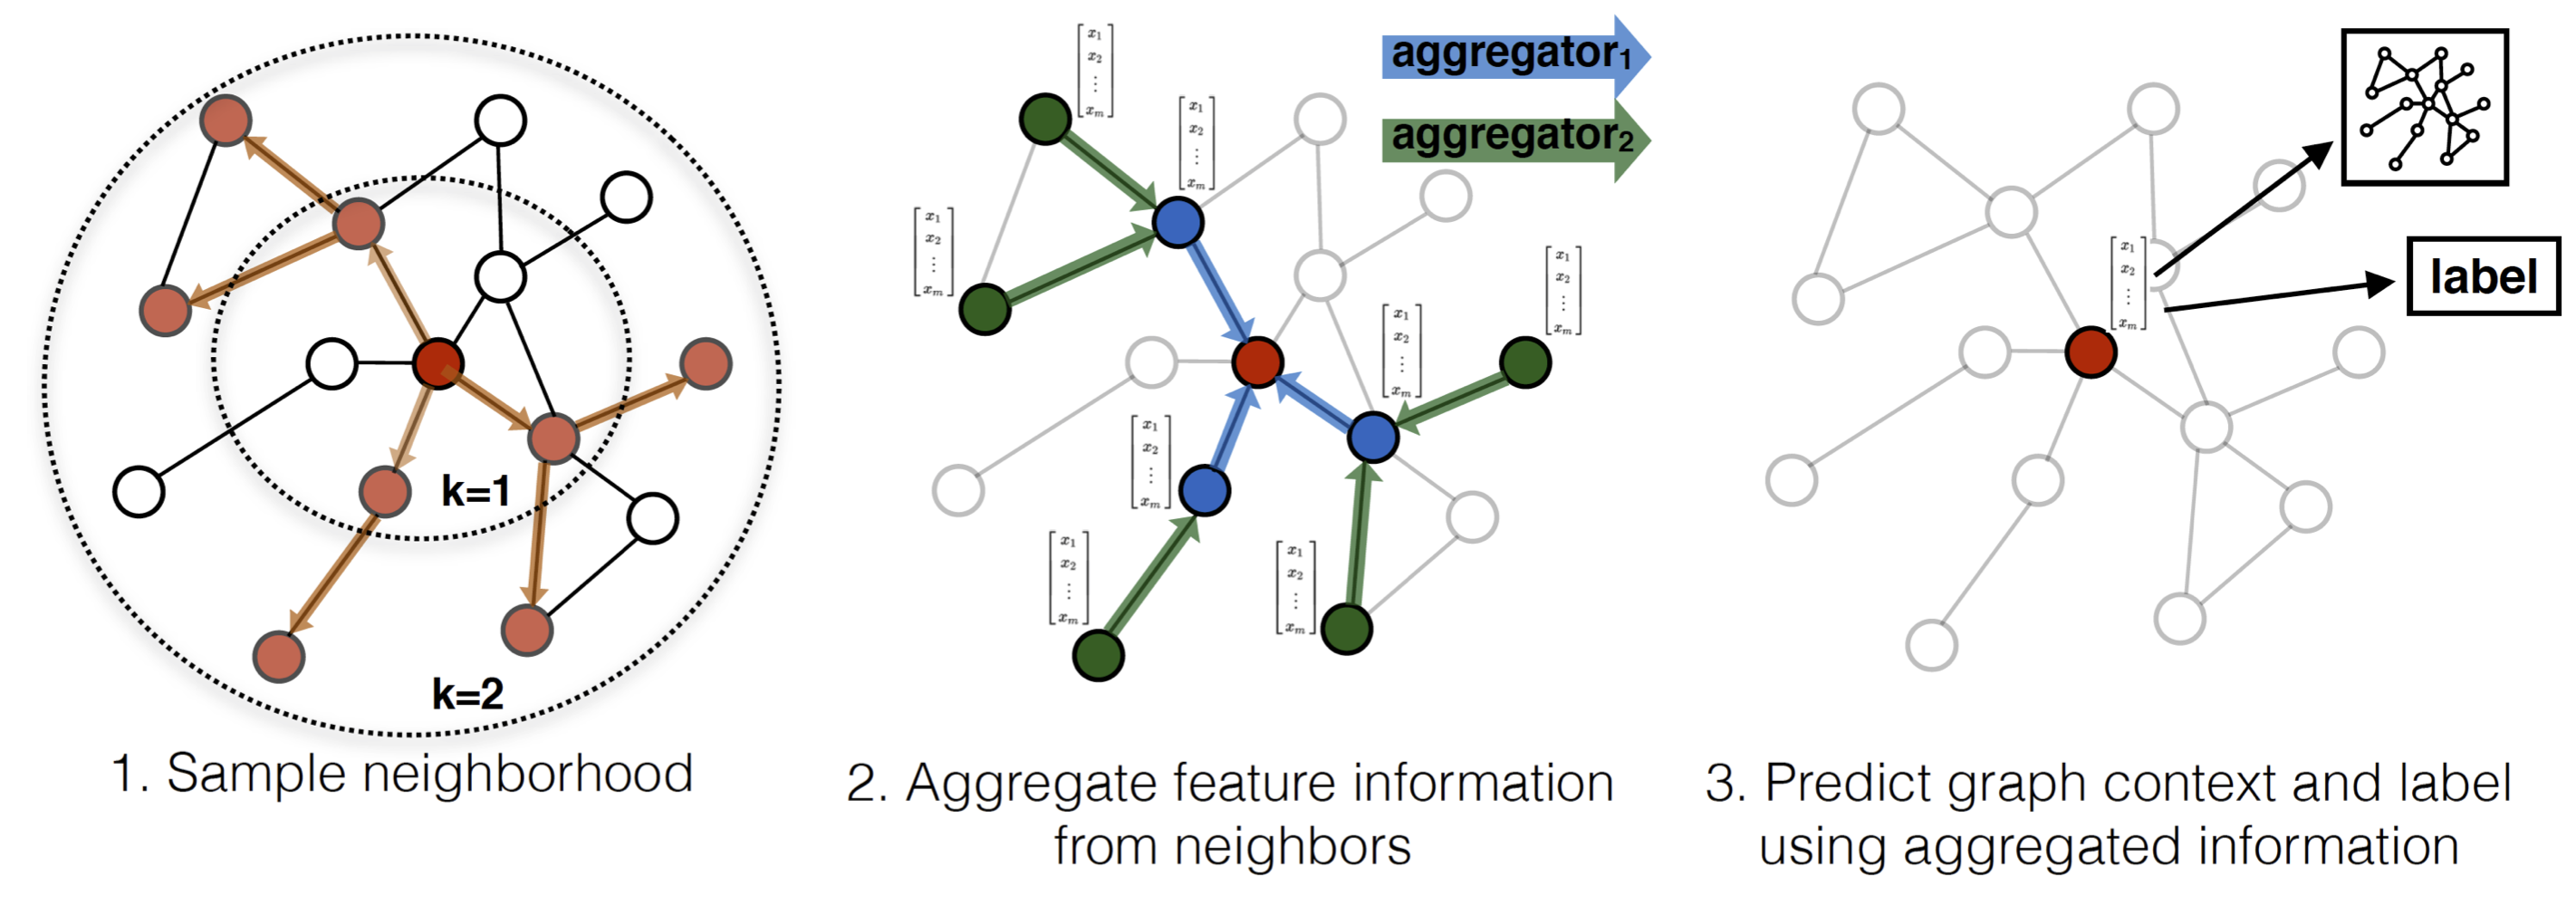

Low-dimensional vector embeddings of nodes in large graphs have numerous applications in machine learning (e.g., node classification, clustering, link prediction). However, most embedding frameworks are inherently transductive and can only generate embeddings for a single fixed graph. These transductive approaches do not efficiently generalize to unseen nodes (e.g., in evolving graphs), and these approaches cannot learn to generalize across different graphs. In contrast, GraphSAGE is an inductive framework that leverages node attribute information to efficiently generate representations on previously unseen data.


#Reference


GraphSAGE:
@inproceedings{hamilton2017inductive,
     author = {Hamilton, William L. and Ying, Rex and Leskovec, Jure},
     title = {Inductive Representation Learning on Large Graphs},
     booktitle = {NIPS},
     year = {2017}
   }

Related reading
1. GraphSAGE for Classification in python.  https://antonsruberts.github.io/graph/graphsage/
2. An introduction to GraphSAGE: https://wandb.ai/graph-neural-networks/GraphSAGE/reports/An-Introduction-to-GraphSAGE--Vmlldzo1MTEwNzQ1
3. GraphSAGE architecture: GraphSAGE Architecture Model ref https://deepgnn.readthedocs.io/en/latest/torch/link_pred.html#

#Hard Negative Sampling
Current Setup: 1 Positive : 10 Negatives
You said you're currently using a 1:10 ratio (very common default). This makes training:

Easier: the model gets to learn what not to connect very clearly

Biased toward negatives: it sees many more "no-link" examples

Potentially overconfident: the model may simply learn to say "no" often and still get high accuracy



#➡️ Try harder negative sampling, like:

Sample 2-hop or same-category nodes as negatives

Sample nodes with similar degree


| Goal                         | Why hard negatives help                                                                                                    |
| ---------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| ✅ **Robustness**             | Your model may be learning shortcuts (like degree or disconnectedness). Hard negatives test *true generalization*.         |
| ✅ **Realism**                | In real-world recommendation or link prediction, false links often *look plausible*. Random negatives don’t simulate that. |
| ✅ **Model validation**       | If your model still performs well on hard negatives, it's a strong sign that your encoder+decoder is meaningful.           |
| ✅ **Avoid overconfidence**   | Easy negatives can inflate metrics — hard negatives test the model's calibration.                                          |
| ✅ **Better ranking quality** | ROC-AUC and F1 might still be high with easy negatives, but link *ranking* may fail in production.                         |
